In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [ ]:
LANE_WIDTH = 5
EPISODE_LEN = 40
SENSOR_RANGE = 3
N_GENES = LANE_WIDTH * (2 ** SENSOR_RANGE)
ACTIONS = [-1, 0, 1]

In [ ]:
def random_genome():
    return [random.choice(ACTIONS) for _ in range(N_GENES)]

In [ ]:
def run_episode(genome, seed=None):
    rng = random.Random(seed)
    position = LANE_WIDTH // 2
    survived = 0

    lanes_ahead = [
        [rng.random() < 0.25 for _ in range(LANE_WIDTH)]
        for _ in range(EPISODE_LEN)
    ]

    for t in range(EPISODE_LEN):
        row = lanes_ahead[t]
        pattern = 0

        for i in range(SENSOR_RANGE):
            idx = min(position + i, LANE_WIDTH - 1)
            pattern = (pattern << 1) | int(row[idx])

        action = genome[
            position * (2 ** SENSOR_RANGE) + pattern
        ]

        position = max(
            0,
            min(LANE_WIDTH - 1, position + action)
        )

        if row[position]:
            break

        survived += 1

    return survived

In [ ]:
def fitness(genome):
    return np.mean([
        run_episode(genome, seed=s)
        for s in range(5)
    ])

In [ ]:
def crossover(g1, g2):
    point = random.randint(1, N_GENES - 1)
    return g1[:point] + g2[point:]

In [ ]:
def mutate(genome, rate=0.03):
    return [
        random.choice(ACTIONS)
        if random.random() < rate
        else g
        for g in genome
    ]

In [ ]:
population = [random_genome() for _ in range(80)]
best_scores = []

In [ ]:
for gen in range(40):
    scored = sorted(population, key=fitness, reverse=True)
    best_scores.append(fitness(scored[0]))

    elites = scored[:12]
    new_pop = elites.copy()

    while len(new_pop) < 80:
        p1, p2 = random.sample(elites, 2)
        new_pop.append(mutate(crossover(p1, p2)))

    population = new_pop

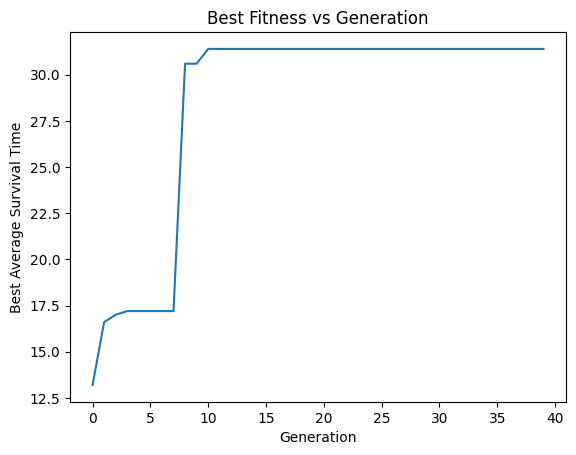

In [ ]:
plt.plot(best_scores)
plt.xlabel("Generation")
plt.ylabel("Best Average Survival Time")
plt.title("Best Fitness vs Generation")
plt.show()